In [3]:
import pandas as pd

# prevent false warning
# https://stackoverflow.com/questions/20625582/how-to-deal-with-settingwithcopywarning-in-pandas
pd.options.mode.chained_assignment = None  # default='warn'

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

import glob

In [52]:



all_files = glob.glob("*.csv")
li = []

for filename in all_files:
    df = pd.read_csv(filename, parse_dates=['start_date', 'end_date'])
    li.append(df)

df = pd.concat(li, axis=0, ignore_index=True)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12767 entries, 0 to 12766
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   hour        12767 non-null  object        
 1   date        0 non-null      float64       
 2   total       12767 non-null  int64         
 3   day         12767 non-null  int64         
 4   overnight   12767 non-null  int64         
 5   start_date  12767 non-null  datetime64[ns]
 6   end_date    12767 non-null  datetime64[ns]
 7   camp        12767 non-null  object        
 8   start_time  12767 non-null  object        
 9   end_time    12767 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(3), object(4)
memory usage: 997.5+ KB


In [54]:
pois = df.camp.unique()

In [55]:
pois

array(['CROCODILE BRIDGE GATE', 'GIRIYONDO BORDER GATE', 'KRUGER GATE',
       'MALELANE GATE', 'NUMBI GATE', 'ORPEN GATE', 'PAFURI GATE',
       'PHABENI GATE', 'PHALABORWA GATE', 'PUNDA MARIA GATE'],
      dtype=object)

In [56]:
gp = df[['start_date', 'total', 'day', 'overnight']].groupby(['start_date']).sum()

In [57]:
gp

,total,day,overnight
start_date,,,
2018-04-01,44325,35037,9288
2018-04-08,28128,21066,7062
2018-04-15,26674,20207,6467
2018-04-22,36889,27610,9279
2018-04-29,41746,33536,8210
...,...,...,...
2020-03-01,27117,20825,6292
2020-03-08,24046,18151,5895
2020-03-15,21508,15073,6435


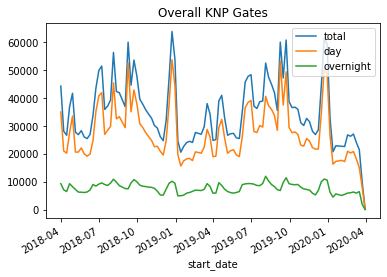

In [58]:
gp.plot()
plt.title('Overall KNP Gates')
plt.show()

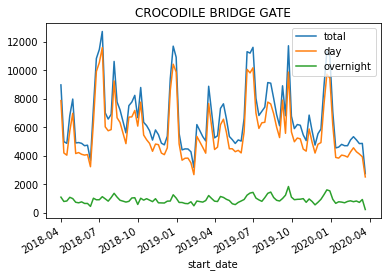

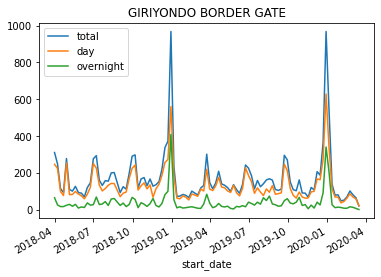

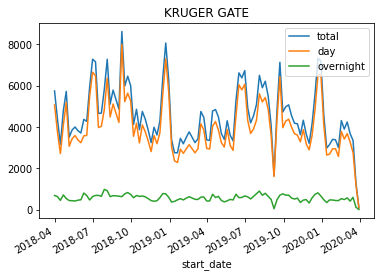

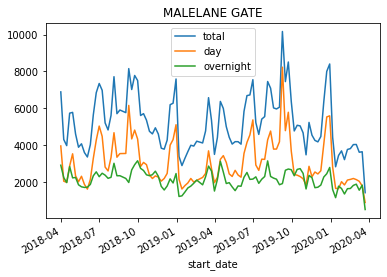

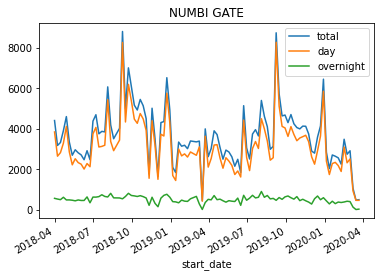

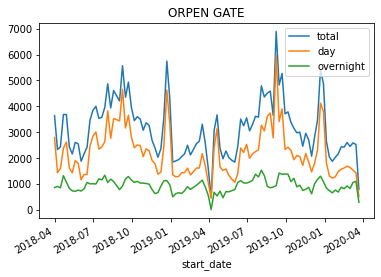

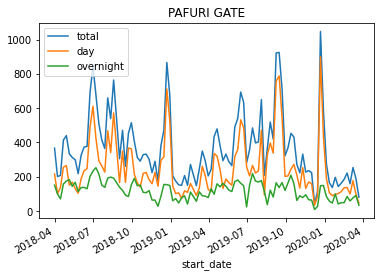

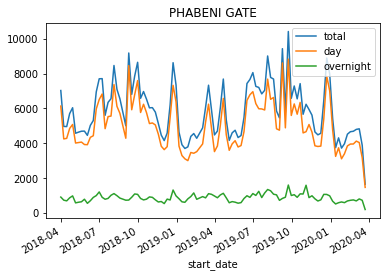

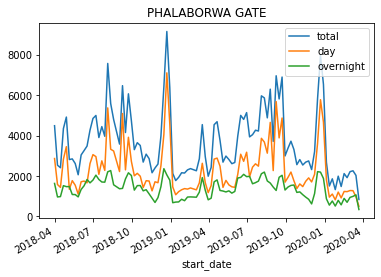

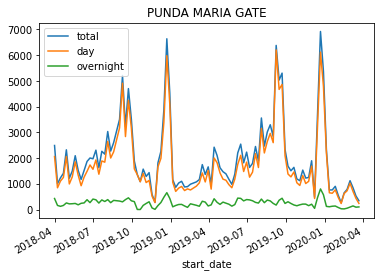

In [59]:
for poi in pois:
    dfx = df[df['camp'] == poi]
    
    gp = dfx[['start_date', 'total', 'day', 'overnight']].groupby(['start_date']).sum()

    
    gp.plot()
    plt.title(poi)
    plt.show()
    

In [60]:
gp = df.groupby(['camp']).sum()

<AxesSubplot:ylabel='total'>

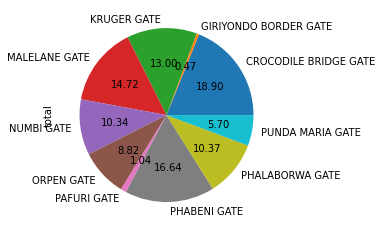

In [61]:
gp['total'].plot.pie(autopct='%.2f')

In [62]:
gp

,date,total,day,overnight
camp,,,,
CROCODILE BRIDGE GATE,0.0,683426,589901,93525
GIRIYONDO BORDER GATE,0.0,17070,13280,3790
KRUGER GATE,0.0,470148,412217,57931
MALELANE GATE,0.0,532147,312956,219191
NUMBI GATE,0.0,374078,322164,51914
ORPEN GATE,0.0,318934,224118,94816
PAFURI GATE,0.0,37708,25535,12173
PHABENI GATE,0.0,601588,514330,87258
PHALABORWA GATE,0.0,375163,234950,140213
